This notebook shows a model predicting medicare payment amount bease on volume, provider type, and risk.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

file_path = "../data/raw/Modified_Prov_Type_and_Round_Int_All_10_years.csv"

usecols = [
    "year",
    "Rndrng_Prvdr_Type",
    "Tot_Benes",
    "Tot_Srvcs",
    "Drug_Tot_Srvcs",
    "Bene_Avg_Risk_Scre",
    "Tot_Mdcr_Pymt_Amt"
]

df = pd.read_csv(file_path, usecols=usecols, low_memory=False)

# sanity check
print(df["year"].min(), df["year"].max())
print(df["year"].value_counts().sort_index().tail())


df.columns.tolist()
df["log_Tot_Benes"] = np.log1p(df["Tot_Benes"])
df["log_Tot_Srvcs"] = np.log1p(df["Tot_Srvcs"])
df["Services_per_Bene"] = df["Tot_Srvcs"] / df["Tot_Benes"].replace(0, np.nan)
df["Drug_Service_Share"] = df["Drug_Tot_Srvcs"] / df["Tot_Srvcs"].replace(0, np.nan)
df["log_Tot_Mdcr_Pymt_Amt"] = np.log1p(df["Tot_Mdcr_Pymt_Amt"])

2013 2023
year
2019    1155870
2020    1161542
2021    1198754
2022    1230293
2023    1259343
Name: count, dtype: int64


In [19]:
type_counts = df["Rndrng_Prvdr_Type"].value_counts()
min_count = 500

keep_types = type_counts[type_counts >= min_count].index

df["ProvType_Model"] = df["Rndrng_Prvdr_Type"].where(
    df["Rndrng_Prvdr_Type"].isin(keep_types),
    "Other"
)
print(df["ProvType_Model"].value_counts().head(20))

ProvType_Model
APP                        2245092
PrimaryCare                2058308
RehabTherapy               1181380
SurgeryOther                982309
Anesthesia                  938813
MedicalSpecialtyOther       915771
FacilitySupplierProgram     640413
AcuteCare                   626097
BehavioralHealth            613971
VisionHearing               596876
RadiologyImaging            365558
OBGYN                       296732
Cardiology                  282461
OncologyHeme                209985
LabPathology                163218
CardioVascularSurgery        76416
PharmacyNutrition            35814
UnknownOther                  2980
Name: count, dtype: int64


These cells are just looking at the dataset as a whole and checking that provider types are organized into sub catagories

## Now a baseline linear regression model

In [22]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

train = df[df["year"] <= 2020].copy()
test  = df[df["year"] >= 2021].copy()

features = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre",
    "ProvType_Model"
]

X_train = train[features]
y_train = train["log_Tot_Mdcr_Pymt_Amt"]

X_test = test[features]
y_test = test["log_Tot_Mdcr_Pymt_Amt"]

categorical_features = ["ProvType_Model"]
numeric_features = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

# Training predictions
train_pred = model.predict(X_train)

# Test predictions
test_pred = model.predict(X_test)

print("TRAIN METRICS")
print("R²:", r2_score(y_train, train_pred))
print("RMSE (log):", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\nTEST METRICS")
print("R²:", r2_score(y_test, test_pred))
print("RMSE (log):", np.sqrt(mean_squared_error(y_test, test_pred)))

TRAIN METRICS
R²: 0.8928390120076847
RMSE (log): 0.502706476511446

TEST METRICS
R²: 0.8808246786596039
RMSE (log): 0.5140390311164488


Note: from RMSE predictions are typically within a factor of ~1.7 of actual payments.
also, ~10% missingness in Drug_Service_Share (division by zero cases), handled via median imputation.

In [26]:
features_no_type = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre"
]

X_train2 = train[features_no_type]
X_test2  = test[features_no_type]

preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), features_no_type)
    ]
)

model2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("regressor", LinearRegression())
])

model2.fit(X_train2, y_train)


train_pred2 = model2.predict(X_train2)

# Test predictions
test_pred2 = model2.predict(X_test2)

print("TRAIN METRICS")
print("R²:", r2_score(y_train, train_pred2))
print("RMSE (log):", np.sqrt(mean_squared_error(y_train, train_pred2)))

print("\nTEST METRICS")
print("R²:", r2_score(y_test, test_pred2))
print("RMSE (log):", np.sqrt(mean_squared_error(y_test, test_pred2)))

TRAIN METRICS
R²: 0.8479543363525708
RMSE (log): 0.5988018661891473

TEST METRICS
R²: 0.8411529952060032
RMSE (log): 0.5934613574664072


A baseline linear regression using volume and beneficiary risk features achieved an out-of-time test R² of 0.84. Incorporating provider specialty (umbrella categories) increased performance to 0.88, indicating that structural differences across clinical domains contribute meaningful additional explanatory power.

# Actual vs Predicted plots

In [28]:
residuals = y_test - test_pred

print("Residual variance:", np.var(residuals))
print("Residual std dev:", np.std(residuals))

Residual variance: 0.2531723339307874
Residual std dev: 0.5031623335771344


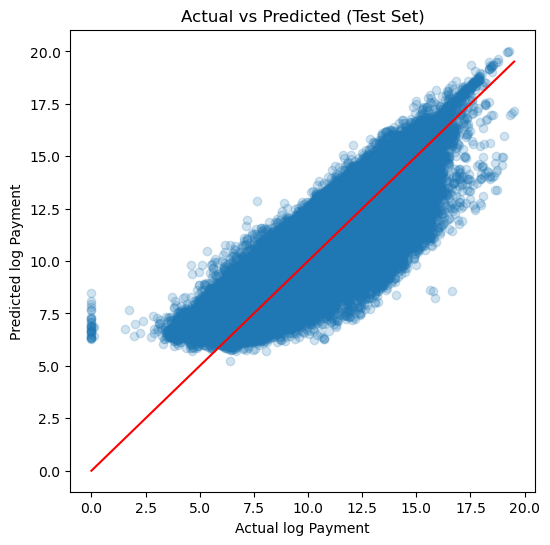

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual log Payment")
plt.ylabel("Predicted log Payment")
plt.title("Actual vs Predicted (Test Set)")
plt.show()

# Residuals

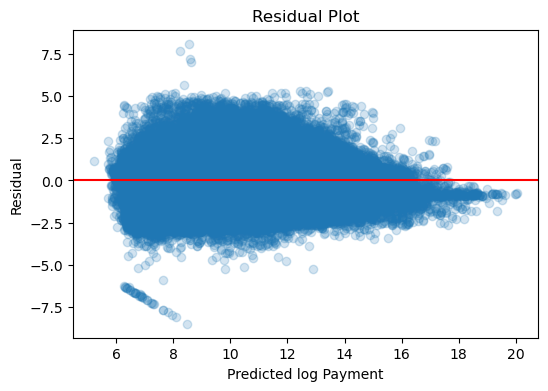

In [30]:
residuals = y_test - test_pred

plt.figure(figsize=(6,4))
plt.scatter(test_pred, residuals, alpha=0.2)
plt.axhline(0, color="red")
plt.xlabel("Predicted log Payment")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

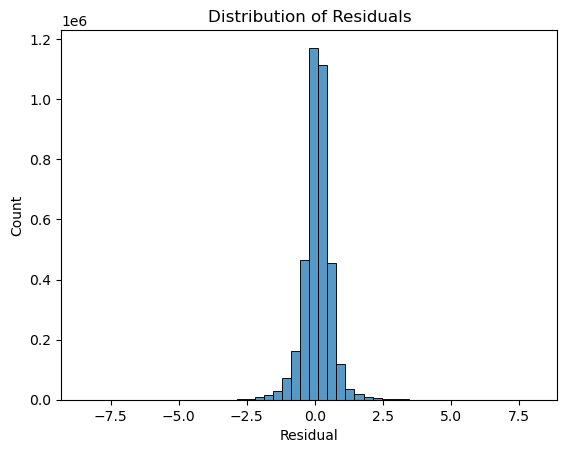

In [32]:
import seaborn as sns

sns.histplot(residuals, bins=50)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

In [33]:
results = pd.DataFrame({
    "Metric": ["Train R2", "Test R2", "Train RMSE", "Test RMSE", "Residual Variance"],
    "Value": [
        r2_score(y_train, train_pred),
        r2_score(y_test, test_pred),
        np.sqrt(mean_squared_error(y_train, train_pred)),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        np.var(residuals)
    ]
})

results

,Metric,Value
0,Train R2,0.892839
1,Test R2,0.880825
2,Train RMSE,0.502706
3,Test RMSE,0.514039
4,Residual Variance,0.253172


# Provider Type Effect (median payments)

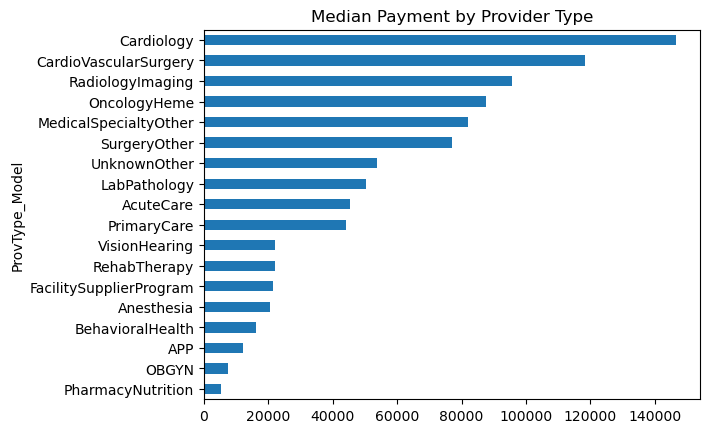

In [12]:
df.groupby("ProvType_Model")["Tot_Mdcr_Pymt_Amt"].median().sort_values().plot(kind="barh")
plt.title("Median Payment by Provider Type")
plt.show()

# Coefficients

In [13]:
import pandas as pd

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
8,cat__ProvType_Model_CardioVascularSurgery,1.356627
3,num__Drug_Service_Share,-0.963438
19,cat__ProvType_Model_SurgeryOther,0.808669
6,cat__ProvType_Model_Anesthesia,0.781996
1,num__log_Tot_Srvcs,0.749682
14,cat__ProvType_Model_OncologyHeme,0.680206
7,cat__ProvType_Model_BehavioralHealth,0.565136
17,cat__ProvType_Model_RadiologyImaging,-0.507128
11,cat__ProvType_Model_LabPathology,-0.440649
5,cat__ProvType_Model_AcuteCare,0.433042


From here we can see CardioVascularSurgery providers have payments almost 4x higher than the baseline provider type(APP) after controlling for volume and risk (makes sense clinically), higher drug share is associated with lower total medicare payment, after controling for volume(drug heavy providers may have fewer serives or drug billing scales differently than procedure billing), Also, log_Tot_Srvcs is ~.75 so a 1% increase in services leads to .75% increase in payment. A 1% increase in beneficiaries leads to a .3% increase in payments (so services matter more than raw beneficiary count)

We can conclude service volume has strong elasticity, while beneficiary count contributes more modestly (.75 vs .3). However, specialty type produces substantial structural shifts in payment levels. Ex. CardioVascularSurgery


In [35]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

features = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre",
    "ProvType_Model"
]

train_sm = train[features + ["log_Tot_Mdcr_Pymt_Amt"]].copy()

# Drop rows with missing values for statsmodels
train_sm = train_sm.dropna()

# One-hot encode provider type
train_sm = pd.get_dummies(train_sm, columns=["ProvType_Model"], drop_first=True)

# Force everything numeric
X = train_sm.drop(columns=["log_Tot_Mdcr_Pymt_Amt"]).astype(float)
y = train_sm["log_Tot_Mdcr_Pymt_Amt"].astype(float)

# Add intercept
X = sm.add_constant(X)

model_sm = sm.OLS(y, X).fit()

print(model_sm.summary())

                              OLS Regression Results                             
Dep. Variable:     log_Tot_Mdcr_Pymt_Amt   R-squared:                       0.896
Model:                               OLS   Adj. R-squared:                  0.896
Method:                    Least Squares   F-statistic:                 3.003e+06
Date:                   Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                           15:20:47   Log-Likelihood:            -5.3716e+06
No. Observations:                7637870   AIC:                         1.074e+07
Df Residuals:                    7637847   BIC:                         1.074e+07
Df Model:                             22                                         
Covariance Type:               nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [36]:
features_no_type = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre"
]

train_sm2 = train[features_no_type + ["log_Tot_Mdcr_Pymt_Amt"]].copy()

train_sm2 = train_sm2.dropna()

X2 = train_sm2.drop(columns=["log_Tot_Mdcr_Pymt_Amt"]).astype(float)
y2 = train_sm2["log_Tot_Mdcr_Pymt_Amt"].astype(float)

X2 = sm.add_constant(X2)

model_sm2 = sm.OLS(y2, X2).fit()

print(model_sm2.summary())

                              OLS Regression Results                             
Dep. Variable:     log_Tot_Mdcr_Pymt_Amt   R-squared:                       0.849
Model:                               OLS   Adj. R-squared:                  0.849
Method:                    Least Squares   F-statistic:                 8.589e+06
Date:                   Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                           16:51:38   Log-Likelihood:            -6.8089e+06
No. Observations:                7637870   AIC:                         1.362e+07
Df Residuals:                    7637864   BIC:                         1.362e+07
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

A linear regression using service volume, patient risk scores, and provider specialty explains roughly 89% of the variation in Medicare payments. Service volume is the strongest driver, while provider specialty introduces large structural differences. For example, cardiovascular surgeons receive nearly four times the Medicare payments of the baseline provider group, even after controlling for service volume and patient risk